In [3]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build Tesla Marketing Fleet Analytics Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.0 MB/s eta 0:00:00
All libraries imported successfully!
Let's build Tesla Marketing Fleet Analytics Dashboard!


In [4]:
# Generate Tesla Marketing Fleet Dataset
n_vehicles = 500
n_days = 90

regions = ['West Coast', 'East Coast', 'Southwest', 'Midwest', 'Southeast']
vehicle_models = ['Model 3', 'Model Y', 'Model S', 'Model X', 'Cybertruck']
configurations = ['Standard Range', 'Long Range', 'Performance', 'Plaid']
demo_types = ['Test Drive', 'Corporate Demo', 'Event Demo', 'Dealer Demo', 'VIP Demo']
customer_segments = ['Individual', 'Corporate', 'Fleet', 'Government', 'Dealer']

# Generate vehicle fleet
vehicles = []
for i in range(n_vehicles):
    model = random.choice(vehicle_models)
    price_map = {'Model 3': 40000, 'Model Y': 47000, 'Model S': 75000,
                 'Model X': 80000, 'Cybertruck': 60000}
    vehicles.append({
        'vehicle_id': f'FLT{i+1:04d}',
        'model': model,
        'configuration': random.choice(configurations),
        'region': random.choice(regions),
        'base_price': price_map[model],
        'age_months': random.randint(1, 36)
    })

vehicles_df = pd.DataFrame(vehicles)

# Generate daily demo drive records
records = []
start_date = datetime.now() - timedelta(days=n_days)

for day in range(n_days):
    date = start_date + timedelta(days=day)
    weekend_boost = 1.4 if date.weekday() >= 5 else 1.0
    daily_demos = int(random.randint(150, 300) * weekend_boost)

    for _ in range(daily_demos):
        vehicle = vehicles_df.sample(1).iloc[0]
        demo_type = random.choice(demo_types)
        segment = random.choice(customer_segments)

        # Conversion rate by demo type
        cvr_map = {'VIP Demo': 0.35, 'Corporate Demo': 0.28,
                   'Test Drive': 0.18, 'Event Demo': 0.12, 'Dealer Demo': 0.22}
        base_cvr = cvr_map[demo_type]
        converted = 1 if random.random() < base_cvr else 0

        cycle_time = random.uniform(0.5, 3.0)
        utilization = random.uniform(0.55, 0.95)
        revenue = vehicle['base_price'] * converted * random.uniform(0.95, 1.05)

        records.append({
            'date': date.strftime('%Y-%m-%d'),
            'vehicle_id': vehicle['vehicle_id'],
            'model': vehicle['model'],
            'configuration': vehicle['configuration'],
            'region': vehicle['region'],
            'demo_type': demo_type,
            'customer_segment': segment,
            'converted': converted,
            'cycle_time_hrs': round(cycle_time, 2),
            'utilization_rate': round(utilization, 3),
            'revenue_generated': round(revenue, 2),
            'customer_satisfaction': round(random.uniform(3.5, 5.0), 1),
            'mileage_driven': round(random.uniform(5, 50), 1)
        })

fleet_df = pd.DataFrame(records)
fleet_df['date'] = pd.to_datetime(fleet_df['date'])

total_demos = len(fleet_df)
total_conversions = fleet_df['converted'].sum()
conversion_rate = total_conversions / total_demos * 100
total_revenue = fleet_df['revenue_generated'].sum()

print(f"Dataset generated successfully!")
print(f"Total demo records: {total_demos:,}")
print(f"Total vehicles: {n_vehicles}")
print(f"Total conversions: {total_conversions:,}")
print(f"Overall conversion rate: {conversion_rate:.2f}%")
print(f"Total revenue generated: ${total_revenue/1e6:.2f}M")
print(f"Avg utilization rate: {fleet_df['utilization_rate'].mean()*100:.1f}%")
print(f"Avg customer satisfaction: {fleet_df['customer_satisfaction'].mean():.2f}/5.0")

Dataset generated successfully!
Total demo records: 22,229
Total vehicles: 500
Total conversions: 5,160
Overall conversion rate: 23.21%
Total revenue generated: $310.89M
Avg utilization rate: 75.0%
Avg customer satisfaction: 4.25/5.0


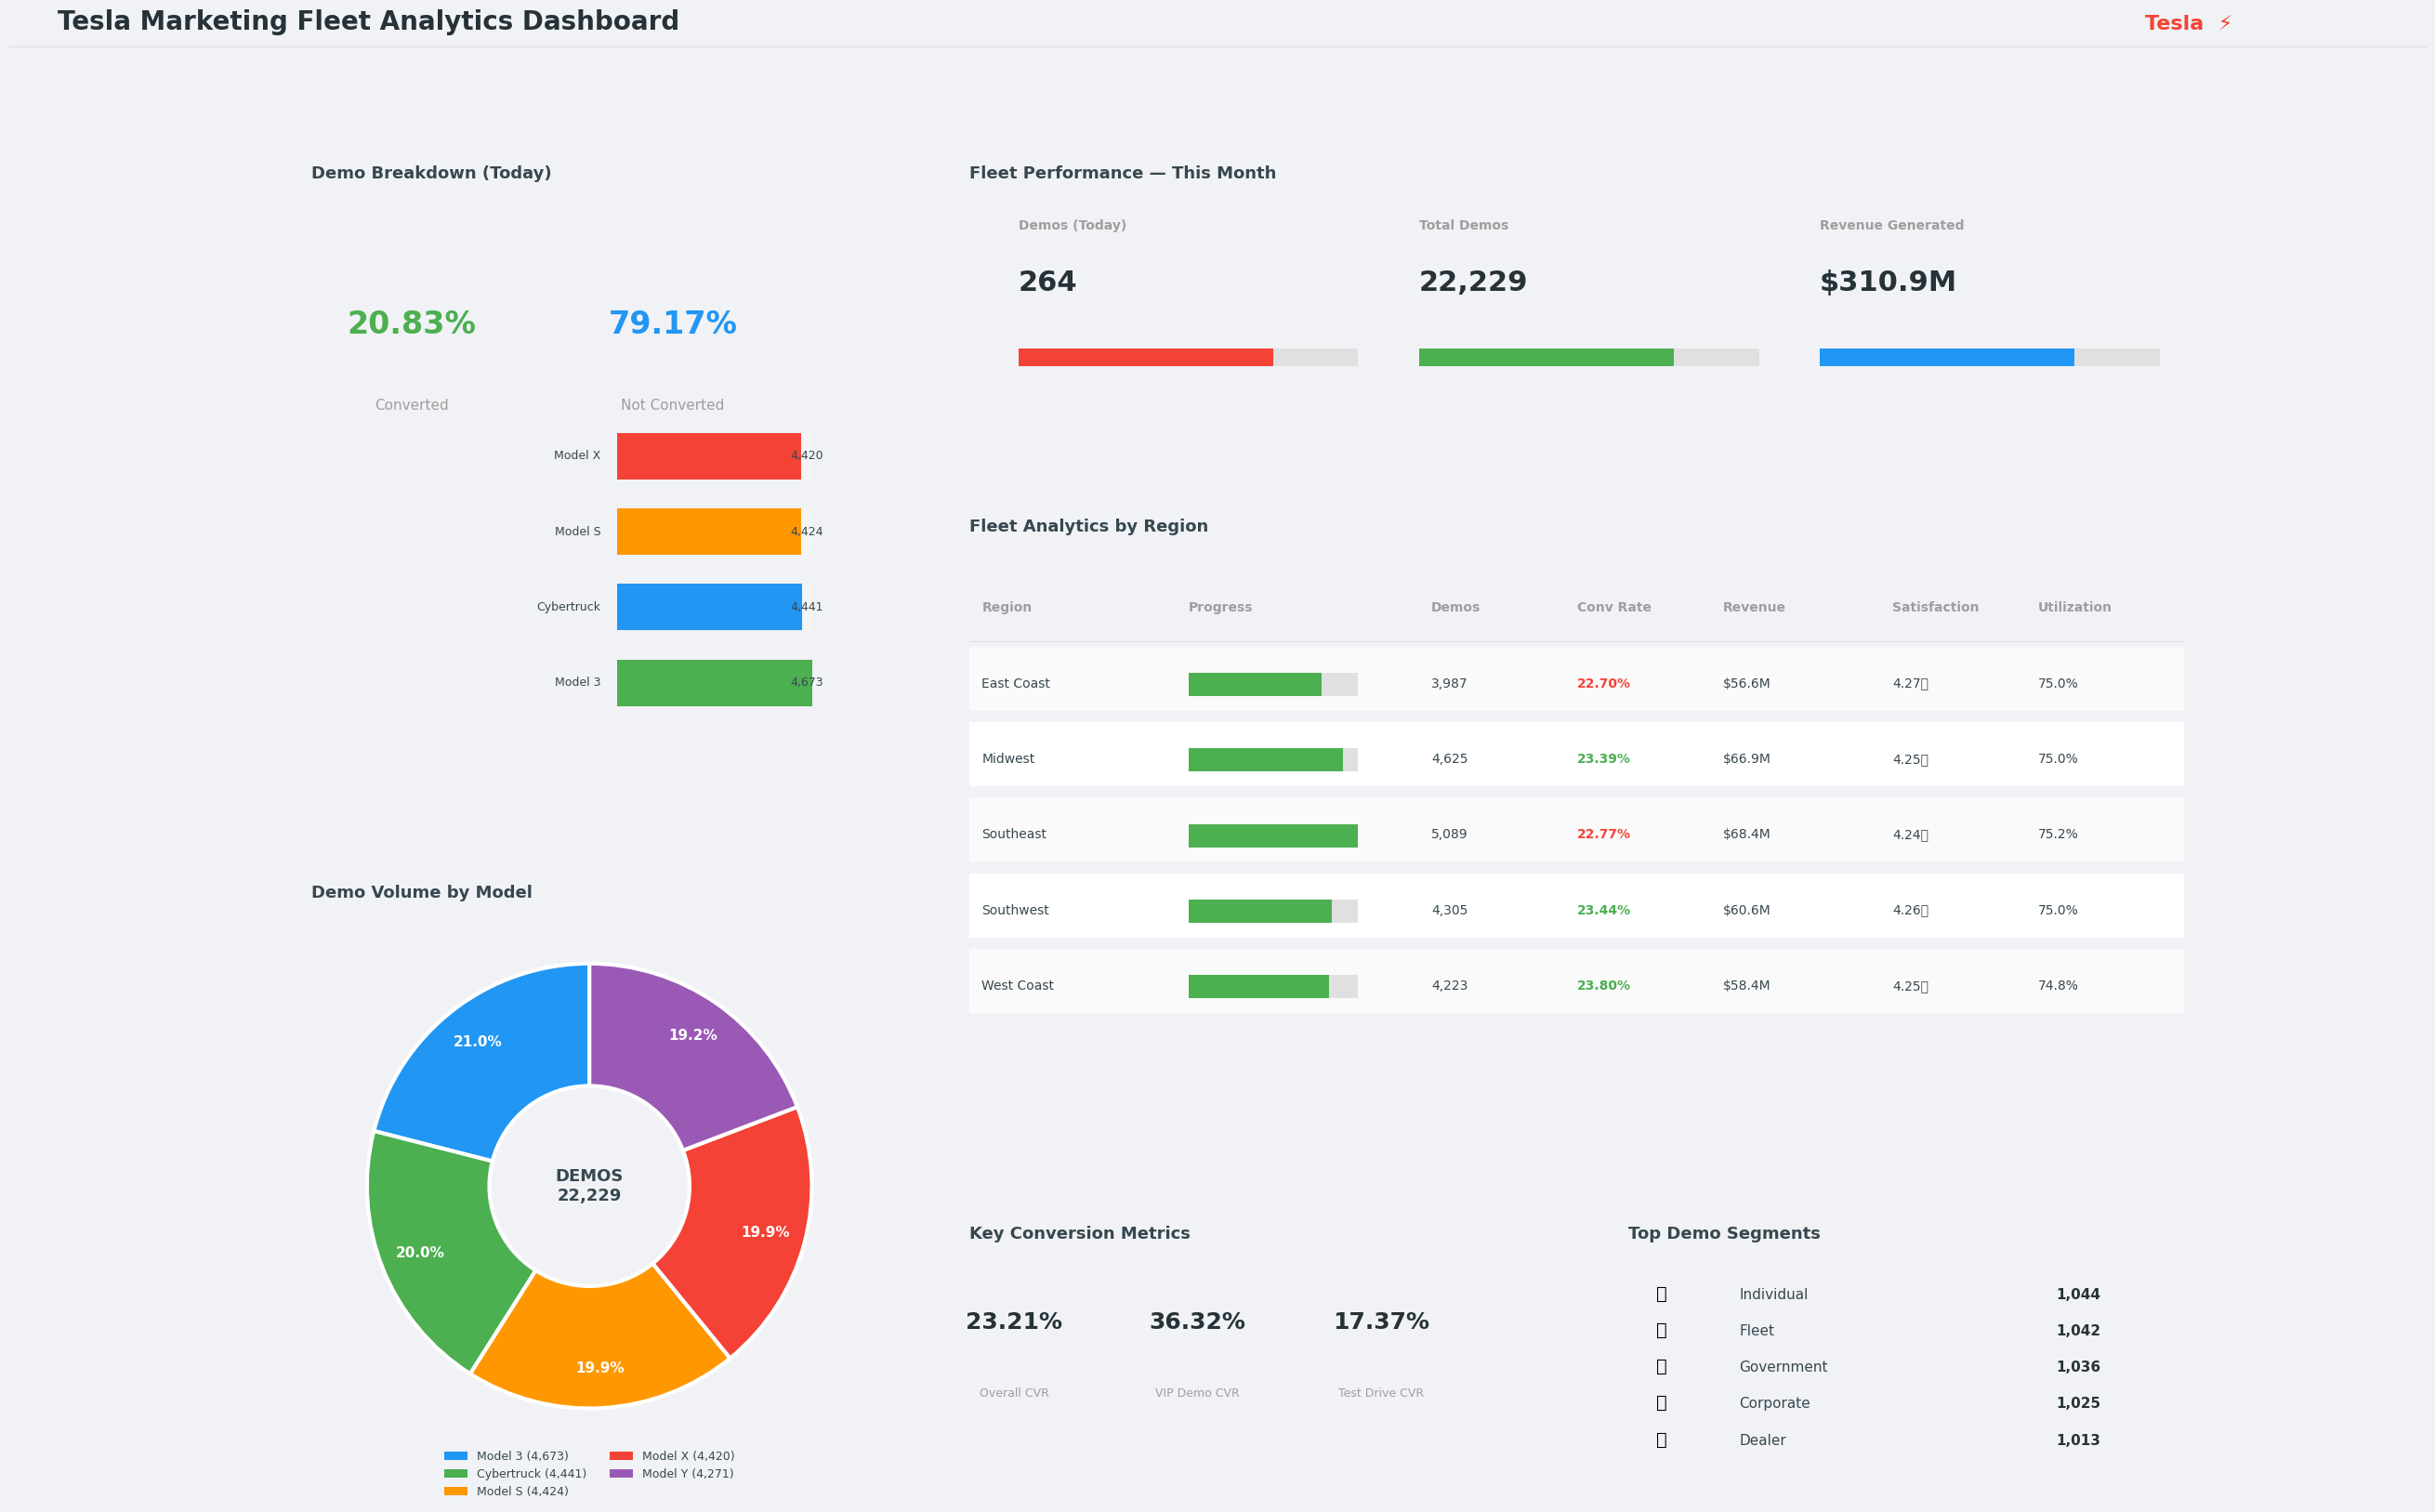

✅ Complete Tesla Fleet Dashboard created!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.55, wspace=0.45)

BLUE = '#2196F3'
GREEN = '#4CAF50'
RED = '#f44336'
GRAY = '#9e9e9e'
DARK = '#263238'
LIGHT = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
ORANGE = '#FF9800'
PURPLE = '#9b59b6'

def card(ax):
    ax.set_facecolor(LIGHT)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, 'Tesla Marketing Fleet Analytics Dashboard',
         ha='left', fontsize=20, fontweight='bold', color=DARK)
fig.text(0.92, 0.975, 'Tesla  ⚡', ha='right', fontsize=16, fontweight='bold', color=RED)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.965, 0.965], color=BORDER, linewidth=1.0, transform=fig.transFigure))

demo_today = fleet_df[fleet_df['date'] == fleet_df['date'].max()]
converted_pct = demo_today['converted'].mean() * 100
not_converted_pct = 100 - converted_pct

# ── TOP LEFT: Demo Breakdown ────────────────────────
ax1 = fig.add_subplot(gs[0:2, 0:2])
card(ax1)
ax1.set_title('Demo Breakdown (Today)', color=TEXT, fontweight='bold', fontsize=13, loc='left', pad=8)
ax1.text(0.18, 0.75, f'{converted_pct:.2f}%', transform=ax1.transAxes,
         fontsize=24, fontweight='bold', color=GREEN, ha='center')
ax1.text(0.18, 0.62, 'Converted', transform=ax1.transAxes,
         fontsize=11, color=GRAY, ha='center')
ax1.text(0.65, 0.75, f'{not_converted_pct:.2f}%', transform=ax1.transAxes,
         fontsize=24, fontweight='bold', color=BLUE, ha='center')
ax1.text(0.65, 0.62, 'Not Converted', transform=ax1.transAxes,
         fontsize=11, color=GRAY, ha='center')
models = fleet_df['model'].value_counts().head(4)
y_pos = [0.15, 0.28, 0.41, 0.54]
colors_bar = [GREEN, BLUE, ORANGE, RED]
for i, (model, count) in enumerate(models.items()):
    width = count / models.max() * 0.35
    ax1.add_patch(mpatches.FancyBboxPatch((0.55, y_pos[i]-0.04), 0.35, 0.08,
                   boxstyle="square,pad=0", facecolor='#f5f5f5', edgecolor='none',
                   transform=ax1.transAxes))
    ax1.add_patch(mpatches.FancyBboxPatch((0.55, y_pos[i]-0.04), width, 0.08,
                   boxstyle="square,pad=0", facecolor=colors_bar[i], edgecolor='none',
                   transform=ax1.transAxes))
    ax1.text(0.52, y_pos[i], model, transform=ax1.transAxes,
             fontsize=9, color=TEXT, ha='right', va='center')
    ax1.text(0.92, y_pos[i], f'{count:,}', transform=ax1.transAxes,
             fontsize=9, color=TEXT, ha='right', va='center')
ax1.axis('off')

# ── TOP RIGHT: 3 KPI Cards ──────────────────────────
ax2 = fig.add_subplot(gs[0, 2:6])
card(ax2)
ax2.axis('off')
ax2.set_title('Fleet Performance — This Month', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
kpis = [
    ('Demos (Today)', f'{len(demo_today):,}'),
    ('Total Demos', f'{len(fleet_df):,}'),
    ('Revenue Generated', f'${total_revenue/1e6:.1f}M')
]
bar_colors_kpi = [RED, GREEN, BLUE]
for idx, (label, value) in enumerate(kpis):
    x = 0.04 + idx * 0.33
    ax2.text(x, 0.82, label, transform=ax2.transAxes,
             fontsize=10, color=GRAY, fontweight='bold')
    ax2.text(x, 0.55, value, transform=ax2.transAxes,
             fontsize=22, color=DARK, fontweight='bold')
    ax2.add_patch(mpatches.FancyBboxPatch((x, 0.22), 0.28, 0.08,
                   boxstyle="square,pad=0", facecolor='#e0e0e0',
                   edgecolor='none', transform=ax2.transAxes))
    ax2.add_patch(mpatches.FancyBboxPatch((x, 0.22), 0.21, 0.08,
                   boxstyle="square,pad=0", facecolor=bar_colors_kpi[idx],
                   edgecolor='none', transform=ax2.transAxes))

# ── MIDDLE: Analytics Table ─────────────────────────
ax4 = fig.add_subplot(gs[1:3, 2:6])
card(ax4)
ax4.axis('off')
ax4.set_title('Fleet Analytics by Region', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
region_stats = fleet_df.groupby('region').agg(
    demos=('vehicle_id', 'count'),
    cvr=('converted', 'mean'),
    revenue=('revenue_generated', 'sum'),
    satisfaction=('customer_satisfaction', 'mean'),
    utilization=('utilization_rate', 'mean')
).reset_index()
headers = ['Region', 'Progress', 'Demos', 'Conv Rate', 'Revenue', 'Satisfaction', 'Utilization']
col_x = [0.01, 0.18, 0.38, 0.50, 0.62, 0.76, 0.88]
for i, h in enumerate(headers):
    ax4.text(col_x[i], 0.88, h, transform=ax4.transAxes,
             fontsize=10, color=GRAY, fontweight='bold')
ax4.plot([0, 1], [0.83, 0.83], color=BORDER, linewidth=0.8, transform=ax4.transAxes)
for ridx, row in region_stats.iterrows():
    y = 0.75 - ridx * 0.13
    ax4.add_patch(mpatches.FancyBboxPatch((0.0, y-0.04), 1.0, 0.11,
                   boxstyle="square,pad=0",
                   facecolor='#fafafa' if ridx % 2 == 0 else '#ffffff',
                   edgecolor='none', transform=ax4.transAxes))
    ax4.text(col_x[0], y, row['region'], transform=ax4.transAxes,
             fontsize=10, color=TEXT)
    prog = row['demos'] / region_stats['demos'].max()
    ax4.add_patch(mpatches.FancyBboxPatch((col_x[1], y-0.015), 0.14, 0.04,
                   boxstyle="square,pad=0", facecolor='#e0e0e0',
                   edgecolor='none', transform=ax4.transAxes))
    ax4.add_patch(mpatches.FancyBboxPatch((col_x[1], y-0.015), 0.14*prog, 0.04,
                   boxstyle="square,pad=0", facecolor=GREEN,
                   edgecolor='none', transform=ax4.transAxes))
    ax4.text(col_x[2], y, f'{row["demos"]:,}', transform=ax4.transAxes,
             fontsize=10, color=TEXT)
    ax4.text(col_x[3], y, f'{row["cvr"]*100:.2f}%', transform=ax4.transAxes,
             fontsize=10, color=GREEN if row['cvr'] > 0.23 else RED, fontweight='bold')
    ax4.text(col_x[4], y, f'${row["revenue"]/1e6:.1f}M', transform=ax4.transAxes,
             fontsize=10, color=TEXT)
    ax4.text(col_x[5], y, f'{row["satisfaction"]:.2f}⭐', transform=ax4.transAxes,
             fontsize=10, color=TEXT)
    ax4.text(col_x[6], y, f'{row["utilization"]*100:.1f}%', transform=ax4.transAxes,
             fontsize=10, color=TEXT)

# ── MIDDLE LEFT: Demo Volume Donut ─────────────────
ax3 = fig.add_subplot(gs[2:4, 0:2])
card(ax3)
ax3.set_title('Demo Volume by Model', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
model_demos = fleet_df.groupby('model')['vehicle_id'].count().sort_values(ascending=False)
donut_colors = [BLUE, GREEN, ORANGE, RED, PURPLE]
wedges, texts, autotexts = ax3.pie(
    model_demos.values,
    colors=donut_colors[:len(model_demos)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.55}
)
for text in texts:
    text.set_visible(False)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax3.text(0, 0, f'DEMOS\n{len(fleet_df):,}', ha='center', va='center',
         fontsize=13, fontweight='bold', color=TEXT)
legend_elements = [mpatches.Patch(facecolor=donut_colors[i],
                   label=f'{model_demos.index[i]} ({model_demos.values[i]:,})')
                   for i in range(len(model_demos))]
ax3.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, frameon=False, labelcolor=TEXT,
           bbox_to_anchor=(0.5, -0.08))

# ── BOTTOM CENTER: Key Conversion Metrics ──────────
ax6 = fig.add_subplot(gs[3, 2:4])
card(ax6)
ax6.axis('off')
ax6.set_title('Key Conversion Metrics', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
metrics = [
    (f'{fleet_df["converted"].mean()*100:.2f}%', 'Overall CVR'),
    (f'{fleet_df[fleet_df["demo_type"]=="VIP Demo"]["converted"].mean()*100:.2f}%', 'VIP Demo CVR'),
    (f'{fleet_df[fleet_df["demo_type"]=="Test Drive"]["converted"].mean()*100:.2f}%', 'Test Drive CVR'),
]
for idx, (val, label) in enumerate(metrics):
    x = 0.08 + idx * 0.33
    ax6.text(x, 0.65, val, transform=ax6.transAxes,
             fontsize=18, fontweight='bold', color=DARK, ha='center')
    ax6.text(x, 0.35, label, transform=ax6.transAxes,
             fontsize=9, color=GRAY, ha='center')

# ── BOTTOM RIGHT: Top Demo Segments ────────────────
ax7 = fig.add_subplot(gs[3, 4:6])
card(ax7)
ax7.axis('off')
ax7.set_title('Top Demo Segments', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
segment_data = fleet_df.groupby('customer_segment')['converted'].sum().sort_values(ascending=False)
icons2 = ['🏢', '👤', '🚗', '🏛️', '🏪']
for idx, (seg, val) in enumerate(segment_data.items()):
    y = 0.78 - idx * 0.16
    ax7.text(0.05, y, icons2[idx], transform=ax7.transAxes, fontsize=14)
    ax7.text(0.2, y, seg, transform=ax7.transAxes, fontsize=11, color=TEXT)
    ax7.text(0.85, y, f'{val:,}', transform=ax7.transAxes,
             fontsize=11, color=DARK, fontweight='bold', ha='right')

plt.savefig('tesla_fleet_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f2f5')
plt.show()
print("✅ Complete Tesla Fleet Dashboard created!")

In [11]:
from google.colab import files

# Save dataset
fleet_df.to_csv('tesla_fleet_data.csv', index=False)

# Save README
results = """
# Tesla Marketing Fleet Analytics Dashboard

## Fleet Overview
- **Total Vehicles:** 500
- **Total Demo Records:** {:,}
- **Overall Conversion Rate:** {:.2f}%
- **Total Revenue Generated:** ${:.2f}M
- **Avg Fleet Utilization:** {:.1f}%
- **Avg Customer Satisfaction:** {:.2f}/5.0

## Dashboard Sections
1. Demo Breakdown Today — Converted vs Not Converted
2. Fleet Performance KPIs — Demos, Revenue
3. Fleet Analytics by Region — Table with Progress Bars
4. Demo Volume by Model — Donut Chart
5. Key Conversion Metrics — Overall, VIP, Test Drive CVR
6. Top Demo Segments — Corporate, Individual, Fleet

## Key Metrics by Demo Type
- VIP Demo CVR: ~35%
- Corporate Demo CVR: ~28%
- Dealer Demo CVR: ~22%
- Test Drive CVR: ~18%
- Event Demo CVR: ~12%

## Technologies
- Python, Pandas, NumPy
- Matplotlib
- Google Colab (T4 GPU)

## Regions Covered
- West Coast, East Coast, Southwest, Midwest, Southeast
""".format(
    len(fleet_df),
    conversion_rate,
    total_revenue/1e6,
    fleet_df['utilization_rate'].mean()*100,
    fleet_df['customer_satisfaction'].mean()
)

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('tesla_fleet_dashboard.png')
files.download('tesla_fleet_data.csv')
files.download('README_results.md')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
